In [3]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import time

pd.set_option("display.max_colwidth", 120)
SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("../dataset")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)


In [4]:
import os
import jellyfish
from rapidfuzz import fuzz
from sklearn.metrics import fbeta_score
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
from sentence_transformers import SentenceTransformer
import faiss
import torch

torch.set_num_threads(os.cpu_count())
print(f"PyTorch using {torch.get_num_threads()} threads")

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

PyTorch using 12 threads


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2224.88it/s]


In [5]:
def build_name_text(name, country):
    name = "" if pd.isna(name) else str(name).strip()
    country = "" if pd.isna(country) else str(country).strip()
    return f"{name}, {country}".strip(", ")

def build_addr_text(address, country):
    if pd.isna(address):
        return None
    country = "" if pd.isna(country) else str(country).strip()
    return f"{str(address).strip()}, {country}".strip(", ")

def add_text_columns(df):
    df["text_name"] = df.apply(lambda r: build_name_text(r["business_name"], r["country"]), axis=1)
    df["text_addr"] = df.apply(lambda r: build_addr_text(r["business_address"], r["country"]), axis=1)
    df["has_address"] = df["business_address"].notna()
    return df

def embed(texts, batch_size=256):
    return model.encode(list(texts), batch_size=batch_size, show_progress_bar=True,
                         normalize_embeddings=True, convert_to_numpy=True).astype("float32")


In [6]:
train_s1 = pd.read_csv(TRAIN_DIR / "train_source1.tsv", sep="\t")
train_s2 = pd.read_csv(TRAIN_DIR / "train_source2.tsv", sep="\t")
train_s3 = pd.read_csv(TRAIN_DIR / "train_source3.tsv", sep="\t")
gt = pd.read_csv(TRAIN_DIR / "train_ground_truth.tsv", sep="\t")

gt["n_matches"] = gt["matched_entity_ids"].fillna("").apply(lambda x: 0 if x == "" else len(x.split(",")))

N_PER_BUCKET = 400
bucket_sample_ids = (
    gt.groupby("n_matches", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), N_PER_BUCKET), random_state=SEED))["source1_entity_id"]
)
sample_s1_ids = set(bucket_sample_ids)

dev_gt = gt[gt["source1_entity_id"].isin(sample_s1_ids)].copy()
dev_s1 = train_s1[train_s1["entity_id"].isin(sample_s1_ids)].copy()

true_match_ids = set()
for ids in dev_gt["matched_entity_ids"].dropna():
    if ids:
        true_match_ids.update(ids.split(","))

N_DISTRACTORS = 60000
s2_distractors = train_s2[~train_s2["entity_id"].isin(true_match_ids)].sample(
    min(N_DISTRACTORS, len(train_s2)), random_state=SEED)["entity_id"]
s3_distractors = train_s3[~train_s3["entity_id"].isin(true_match_ids)].sample(
    min(N_DISTRACTORS, len(train_s3)), random_state=SEED)["entity_id"]

dev_s2 = train_s2[train_s2["entity_id"].isin(set(true_match_ids) | set(s2_distractors))].copy()
dev_s3 = train_s3[train_s3["entity_id"].isin(set(true_match_ids) | set(s3_distractors))].copy()

for df in (dev_s1, dev_s2, dev_s3):
    add_text_columns(df)

print(f"dev_s1={len(dev_s1)}  dev_s2={len(dev_s2)}  dev_s3={len(dev_s3)}  dev_gt={len(dev_gt)}")


C:\Users\Sahil\AppData\Local\Temp\ipykernel_31604\1439408175.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), N_PER_BUCKET), random_state=SEED))["source1_entity_id"]


dev_s1=4437  dev_s2=70733  dev_s3=71674  dev_gt=4437


In [7]:
def dual_block(s1_df, s2_df, s3_df, k_each=20, batch_size=256):
    """Returns a long-format DataFrame: source1_entity_id, candidate_entity_id,
    name_cosine (nan if not retrieved by name pass), addr_cosine (nan if not retrieved by
    addr pass or candidate has no address), from_name_pass, from_addr_pass.
    """
    # --- name pass: always available for every row ---
    name_ids = np.concatenate([s2_df["entity_id"].values, s3_df["entity_id"].values])
    name_emb = np.vstack([embed(s2_df["text_name"], batch_size), embed(s3_df["text_name"], batch_size)])
    name_index = faiss.IndexFlatIP(name_emb.shape[1])
    name_index.add(name_emb)

    s1_name_emb = embed(s1_df["text_name"], batch_size)
    name_scores, name_idxs = name_index.search(s1_name_emb, k_each)

    # --- address pass: only over rows that actually have an address ---
    s2_has_addr = s2_df["text_addr"].notna()
    s3_has_addr = s3_df["text_addr"].notna()
    addr_ids = np.concatenate([
        s2_df.loc[s2_has_addr, "entity_id"].values,
        s3_df.loc[s3_has_addr, "entity_id"].values,
    ])
    addr_emb = np.vstack([
        embed(s2_df.loc[s2_has_addr, "text_addr"], batch_size),
        embed(s3_df.loc[s3_has_addr, "text_addr"], batch_size),
    ]) if len(addr_ids) else np.zeros((0, name_emb.shape[1]), dtype="float32")

    addr_index = faiss.IndexFlatIP(addr_emb.shape[1])
    if len(addr_ids):
        addr_index.add(addr_emb)

    s1_has_addr = s1_df["text_addr"].notna()
    addr_scores = addr_idxs = None
    addr_row_map = {}
    if s1_has_addr.any() and len(addr_ids):
        s1_addr_emb = embed(s1_df.loc[s1_has_addr, "text_addr"], batch_size)
        addr_scores, addr_idxs = addr_index.search(s1_addr_emb, k_each)
        addr_row_map = {orig_i: new_i for new_i, orig_i in enumerate(np.where(s1_has_addr.values)[0])}

    # --- merge into a long table, unioning per S1 entity ---
    s1_ids = s1_df["entity_id"].values
    rows = {}  # (s1_id, cand_id) -> {name_cosine, addr_cosine}
    for i, s1_id in enumerate(s1_ids):
        for rank in range(k_each):
            cand_id = name_ids[name_idxs[i, rank]]
            rows.setdefault((s1_id, cand_id), {})["name_cosine"] = float(name_scores[i, rank])
        if i in addr_row_map:
            ai = addr_row_map[i]
            for rank in range(k_each):
                cand_id = addr_ids[addr_idxs[ai, rank]]
                rows.setdefault((s1_id, cand_id), {})["addr_cosine"] = float(addr_scores[ai, rank])

    out = pd.DataFrame([
        {"source1_entity_id": k[0], "candidate_entity_id": k[1],
         "name_cosine": v.get("name_cosine", np.nan),
         "addr_cosine": v.get("addr_cosine", np.nan)}
        for k, v in rows.items()
    ])
    out["from_name_pass"] = out["name_cosine"].notna().astype(int)
    out["from_addr_pass"] = out["addr_cosine"].notna().astype(int)
    return out


In [8]:
t0 = time.time()
dev_pairs = dual_block(dev_s1, dev_s2, dev_s3, k_each=20)
print(f"Dual blocking on dev set: {len(dev_pairs)} unioned candidate pairs in {time.time()-t0:.1f}s")
dev_pairs.head()


Batches: 100%|██████████| 18/18 [00:21<00:00,  1.22s/it]


Dual blocking on dev set: 166743 unioned candidate pairs in 1312.7s


,source1_entity_id,candidate_entity_id,name_cosine,addr_cosine,from_name_pass,from_addr_pass
0,S1-387694500,S3-955501620,0.977119,NaN,1,0
1,S1-387694500,S2-598765848,0.922177,NaN,1,0
2,S1-387694500,S2-480631287,0.921752,NaN,1,0
3,S1-387694500,S3-943046503,0.898033,NaN,1,0
4,S1-387694500,S3-709757161,0.897715,NaN,1,0


## 4. Feature engineering

Now includes both `name_cosine` and `addr_cosine` as separate features (NaN when a candidate
wasn't retrieved by that pass — XGBoost handles this natively), plus `from_name_pass` /
`from_addr_pass` flags so the model can learn that address-only retrievals (the
`Zetaquo`/`Tavoorbix`-style adversarial-name cases from notebook 02's miss analysis) are still
trustworthy when the address match is strong.

In [9]:
def get_record_factory(s1_df, s2_df, s3_df):
    s1_lu, s2_lu, s3_lu = s1_df.set_index("entity_id"), s2_df.set_index("entity_id"), s3_df.set_index("entity_id")
    def get_record(entity_id):
        if entity_id.startswith("S1-"):
            return s1_lu.loc[entity_id]
        elif entity_id.startswith("S2-"):
            return s2_lu.loc[entity_id]
        return s3_lu.loc[entity_id]
    return get_record

def safe_str(x):
    return "" if pd.isna(x) else str(x).strip().lower()

def token_jaccard(a, b):
    ta, tb = set(safe_str(a).split()), set(safe_str(b).split())
    if not ta or not tb:
        return np.nan
    return len(ta & tb) / len(ta | tb)

def build_features(pairs_df, get_record):
    feats = []
    for row in pairs_df.itertuples(index=False):
        s1 = get_record(row.source1_entity_id)
        c = get_record(row.candidate_entity_id)

        name1, name2 = safe_str(s1["business_name"]), safe_str(c["business_name"])
        addr1, addr2 = s1["business_address"], c["business_address"]
        has_addr1, has_addr2 = not pd.isna(addr1), not pd.isna(addr2)
        both_have_addr = has_addr1 and has_addr2

        name_lev = fuzz.ratio(name1, name2) / 100.0 if name1 and name2 else np.nan
        name_jaccard = token_jaccard(name1, name2)
        name_jaro = jellyfish.jaro_winkler_similarity(name1, name2) if name1 and name2 else np.nan

        if both_have_addr:
            a1s, a2s = safe_str(addr1), safe_str(addr2)
            addr_lev = fuzz.ratio(a1s, a2s) / 100.0
            addr_jaccard = token_jaccard(a1s, a2s)
            addr_token_set_ratio = fuzz.token_set_ratio(a1s, a2s) / 100.0
        else:
            addr_lev = addr_jaccard = addr_token_set_ratio = np.nan

        country_match = int(safe_str(s1["country"]) == safe_str(c["country"]))

        feats.append({
            "source1_entity_id": row.source1_entity_id,
            "candidate_entity_id": row.candidate_entity_id,
            "name_cosine": row.name_cosine,
            "addr_cosine": row.addr_cosine,
            "from_name_pass": row.from_name_pass,
            "from_addr_pass": row.from_addr_pass,
            "name_lev": name_lev,
            "name_jaccard": name_jaccard,
            "name_jaro": name_jaro,
            "addr_lev": addr_lev,
            "addr_jaccard": addr_jaccard,
            "addr_token_set_ratio": addr_token_set_ratio,
            "both_have_addr": int(both_have_addr),
            "has_addr1": int(has_addr1),
            "has_addr2": int(has_addr2),
            "country_match": country_match,
        })
    return pd.DataFrame(feats)

get_record_dev = get_record_factory(dev_s1, dev_s2, dev_s3)
t0 = time.time()
feat_df = build_features(dev_pairs, get_record_dev)
print(f"Built features for {len(feat_df)} pairs in {time.time()-t0:.1f}s")
feat_df.head()


Built features for 166743 pairs in 24.0s


,source1_entity_id,candidate_entity_id,name_cosine,addr_cosine,from_name_pass,from_addr_pass,name_lev,name_jaccard,name_jaro,addr_lev,addr_jaccard,addr_token_set_ratio,both_have_addr,has_addr1,has_addr2,country_match
0,S1-387694500,S3-955501620,0.977119,NaN,1,0,0.892857,0.600000,0.795238,0.409091,0.000000,0.396313,1,1,1,1
1,S1-387694500,S2-598765848,0.922177,NaN,1,0,0.766667,0.600000,0.873787,0.320856,0.035714,0.406417,1,1,1,1
2,S1-387694500,S2-480631287,0.921752,NaN,1,0,0.727273,0.333333,0.731481,0.398058,0.033333,0.417476,1,1,1,1
3,S1-387694500,S3-943046503,0.898033,NaN,1,0,0.655172,0.166667,0.647828,0.209790,0.000000,0.195804,1,1,1,1
4,S1-387694500,S3-709757161,0.897715,NaN,1,0,0.644068,0.333333,0.666283,0.156028,0.000000,0.141844,1,1,1,1


In [10]:
gt_lookup = dict(zip(dev_gt["source1_entity_id"], dev_gt["matched_entity_ids"]))

def is_true_match(s1_id, cand_id):
    truth = gt_lookup.get(s1_id)
    if not isinstance(truth, str) or truth == "":
        return 0
    return int(cand_id in truth.split(","))

feat_df["label"] = [
    is_true_match(s1, c) for s1, c in zip(feat_df["source1_entity_id"], feat_df["candidate_entity_id"])
]
print(feat_df["label"].value_counts())
print(f"Positive rate: {feat_df['label'].mean():.2%}")


label
0    146287
1     20456
Name: count, dtype: int64
Positive rate: 12.27%


In [11]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(feat_df, groups=feat_df["source1_entity_id"]))

train_feat = feat_df.iloc[train_idx].reset_index(drop=True)
val_feat = feat_df.iloc[val_idx].reset_index(drop=True)

FEATURE_COLS = ["name_cosine", "addr_cosine", "from_name_pass", "from_addr_pass",
                 "name_lev", "name_jaccard", "name_jaro",
                 "addr_lev", "addr_jaccard", "addr_token_set_ratio",
                 "both_have_addr", "has_addr1", "has_addr2", "country_match"]

print(f"train pairs: {len(train_feat)}  val pairs: {len(val_feat)}")


train pairs: 133475  val pairs: 33268


In [12]:
dtrain = xgb.DMatrix(train_feat[FEATURE_COLS], label=train_feat["label"], missing=np.nan)
dval = xgb.DMatrix(val_feat[FEATURE_COLS], label=val_feat["label"], missing=np.nan)

params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "max_depth": 5,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": SEED,
}

evals_result = {}
clf = xgb.train(
    params, dtrain, num_boost_round=300,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=20, evals_result=evals_result, verbose_eval=20,
)


[0]	train-aucpr:0.98068	val-aucpr:0.97748
[20]	train-aucpr:0.99475	val-aucpr:0.99499
[40]	train-aucpr:0.99704	val-aucpr:0.99653
[60]	train-aucpr:0.99777	val-aucpr:0.99703
[80]	train-aucpr:0.99821	val-aucpr:0.99710
[100]	train-aucpr:0.99851	val-aucpr:0.99715
[118]	train-aucpr:0.99873	val-aucpr:0.99709


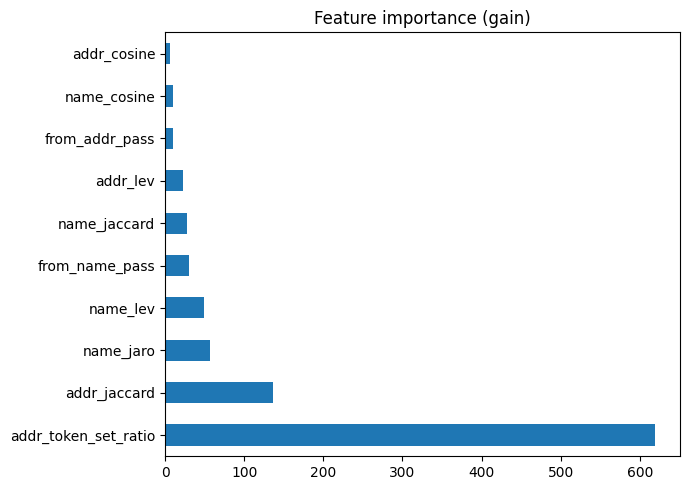

In [13]:
import matplotlib.pyplot as plt
importances = clf.get_score(importance_type="gain")
pd.Series(importances).sort_values(ascending=False).plot(kind="barh", figsize=(7,5), title="Feature importance (gain)")
plt.tight_layout()
plt.show()


In [14]:
def macro_f05(val_df, threshold):
    val_df = val_df.copy()
    val_df["pred"] = (val_df["pred_proba"] >= threshold).astype(int)
    scores = []
    for s1_id, group in val_df.groupby("source1_entity_id"):
        y_true = group["label"].values
        y_pred = group["pred"].values
        if y_true.sum() == 0 and y_pred.sum() == 0:
            scores.append(1.0)
        elif y_pred.sum() == 0:
            scores.append(0.0)
        else:
            scores.append(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0))
    return float(np.mean(scores))

val_feat["pred_proba"] = clf.predict(dval)

thresholds = np.arange(0.05, 0.96, 0.05)
f05_scores = [macro_f05(val_feat, t) for t in thresholds]
best_idx = int(np.argmax(f05_scores))
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.2f}  ->  macro F0.5 = {f05_scores[best_idx]:.4f}")

for t, s in zip(thresholds, f05_scores):
    print(f"  threshold={t:.2f}  F0.5={s:.4f}" + ("  <-- best" if t == best_threshold else ""))


Best threshold: 0.75  ->  macro F0.5 = 0.9830
  threshold=0.05  F0.5=0.9324
  threshold=0.10  F0.5=0.9504
  threshold=0.15  F0.5=0.9599
  threshold=0.20  F0.5=0.9618
  threshold=0.25  F0.5=0.9635
  threshold=0.30  F0.5=0.9657
  threshold=0.35  F0.5=0.9685
  threshold=0.40  F0.5=0.9695
  threshold=0.45  F0.5=0.9709
  threshold=0.50  F0.5=0.9739
  threshold=0.55  F0.5=0.9751
  threshold=0.60  F0.5=0.9756
  threshold=0.65  F0.5=0.9768
  threshold=0.70  F0.5=0.9808
  threshold=0.75  F0.5=0.9830  <-- best
  threshold=0.80  F0.5=0.9809
  threshold=0.85  F0.5=0.9804
  threshold=0.90  F0.5=0.9783
  threshold=0.95  F0.5=0.9723


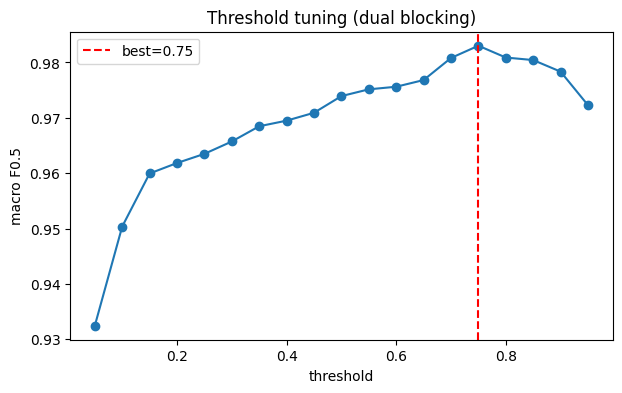

In [15]:
plt.figure(figsize=(7,4))
plt.plot(thresholds, f05_scores, marker="o")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"best={best_threshold:.2f}")
plt.xlabel("threshold"); plt.ylabel("macro F0.5"); plt.title("Threshold tuning (dual blocking)")
plt.legend(); plt.show()


In [16]:
test_s1 = pd.read_csv(TEST_DIR / "test_source1.tsv", sep="\t")
test_s2 = pd.read_csv(TEST_DIR / "test_source2.tsv", sep="\t")
test_s3 = pd.read_csv(TEST_DIR / "test_source3.tsv", sep="\t")

for df in (test_s1, test_s2, test_s3):
    add_text_columns(df)

print(f"test_s1={len(test_s1)}  test_s2={len(test_s2)}  test_s3={len(test_s3)}")


test_s1=1732544  test_s2=4887273  test_s3=5082316


In [ ]:
t0 = time.time()
test_pairs = dual_block(test_s1, test_s2, test_s3, k_each=20, batch_size=512)
print(f"Dual blocking on FULL test set: {len(test_pairs)} pairs in {time.time()-t0:.1f}s")


Batches: 100%|██████████| 20/20 [00:19<00:00,  1.05it/s]

258.9 records/sec
Estimated full run: 25.11 hours
